# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
num_replys_anotados = 100
num_quotes_anotados = 100
num_originals_anotados = 100

# **Pares Tweets-Reply**

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1HpXPp20WUJOooGMVBZjuk34zo9enlTZp"
file_class_victor = "1R3UoDhpJItZ7DlxIPzcMpx96r8nNJr2F"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Contas_suspensas_reply_caio.csv", quiet=False)
gdown.download(url_2, "Contas_suspensas_reply_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1HpXPp20WUJOooGMVBZjuk34zo9enlTZp
To: /content/Contas_suspensas_reply_caio.csv
100%|██████████| 1.69M/1.69M [00:00<00:00, 17.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1R3UoDhpJItZ7DlxIPzcMpx96r8nNJr2F
To: /content/Contas_suspensas_reply_victor.csv
100%|██████████| 1.69M/1.69M [00:00<00:00, 18.9MB/s]


'Contas_suspensas_reply_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("Contas_suspensas_reply_caio.csv")
df_victor = pd.read_csv ("Contas_suspensas_reply_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(5704, 4)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(5704, 4)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,Conflict
0,Vocês também estão sentindo que o clima aqui n...,Comunista defendendo a censura. Nada de novo p...,1,1.0
1,O tiranete Alexandre de Moraes passou de todos...,Eu não consigo ler isso sem passar raiva desse...,1,0.0
2,O tiranete Alexandre de Moraes passou de todos...,"Isso é total ditadura!! Mas e o executivo , nã...",1,0.0
3,"Hoje, 24/07, Fakhoury e demais investigados pe...","... o PGR, Augusto Aras, já opinou pela conces...",1,0.0
4,É verdade que o Twitter derrubou várias contas...,"Dessa vez a culpa não foi do Twitter, e sim do...",1,0.0
5,Várias contas foram retidas do Twitter sob a j...,"CENSURA descarada! "" Tomar o poder é diferente...",1,0.0
6,"Podemos até usar este truque, mas precisamos l...","Concordo, não podemos nos confirmar #VozParaBe...",1,0.0
7,"Contei na abertura do 360: no último dia 22, o...","Em contrapartida, a dá espaço para o Roberto ...",1,0.0
8,"... o PGR, Augusto Aras, já opinou pela conces...",...garantida pelo amplo sistema de liberdade d...,1,0.0
9,Liberdade de expressão! #VozParaBernardoKuster,Não vão calar a direita. #VozParaBernardoKuster,1,0.0


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,Conflict
0,Vocês também estão sentindo que o clima aqui n...,Comunista defendendo a censura. Nada de novo p...,1,1.0
1,O tiranete Alexandre de Moraes passou de todos...,Eu não consigo ler isso sem passar raiva desse...,1,0.0
2,O tiranete Alexandre de Moraes passou de todos...,"Isso é total ditadura!! Mas e o executivo , nã...",1,0.0
3,"Hoje, 24/07, Fakhoury e demais investigados pe...","... o PGR, Augusto Aras, já opinou pela conces...",1,0.0
4,É verdade que o Twitter derrubou várias contas...,"Dessa vez a culpa não foi do Twitter, e sim do...",1,0.0
5,Várias contas foram retidas do Twitter sob a j...,"CENSURA descarada! "" Tomar o poder é diferente...",1,0.0
6,"Podemos até usar este truque, mas precisamos l...","Concordo, não podemos nos confirmar #VozParaBe...",1,0.0
7,"Contei na abertura do 360: no último dia 22, o...","Em contrapartida, a dá espaço para o Roberto ...",1,1.0
8,"... o PGR, Augusto Aras, já opinou pela conces...",...garantida pelo amplo sistema de liberdade d...,1,0.0
9,Liberdade de expressão! #VozParaBernardoKuster,Não vão calar a direita. #VozParaBernardoKuster,1,0.0


In [10]:
df_caio = df_caio.iloc[:num_replys_anotados,:]
df_victor = df_victor.iloc[:num_replys_anotados,:]

In [11]:
df_caio

,tweet_1,tweet_2,Class,Conflict
0,Vocês também estão sentindo que o clima aqui n...,Comunista defendendo a censura. Nada de novo p...,1,1.0
1,O tiranete Alexandre de Moraes passou de todos...,Eu não consigo ler isso sem passar raiva desse...,1,0.0
2,O tiranete Alexandre de Moraes passou de todos...,"Isso é total ditadura!! Mas e o executivo , nã...",1,0.0
3,"Hoje, 24/07, Fakhoury e demais investigados pe...","... o PGR, Augusto Aras, já opinou pela conces...",1,0.0
4,É verdade que o Twitter derrubou várias contas...,"Dessa vez a culpa não foi do Twitter, e sim do...",1,0.0
...,...,...,...,...
95,"Por ordem de Alexandre de Moraes, Twitter canc...","Professor, para ver as contas que foram retida...",1,0.0
96,Vivemos em uma ditadura da toga #VozParaBernar...,Espalhar fakenews e discursos de ódio não tem ...,1,1.0
97,", não é Censura. Não é Crime de Opinião. Liber...",é censura sim... a lei já prevê os crimes cont...,1,1.0
98,Vivemos em uma ditadura da toga #VozParaBernar...,Bora levantar #VozParaBernardoKuster,1,0.0


In [12]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem


In [13]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [14]:
confusion

array([[66.,  2.,  2.],
       [ 1., 28.,  0.],
       [ 1.,  0.,  0.]])

In [15]:
idx_diff

[7, 12, 33, 51, 83, 90]

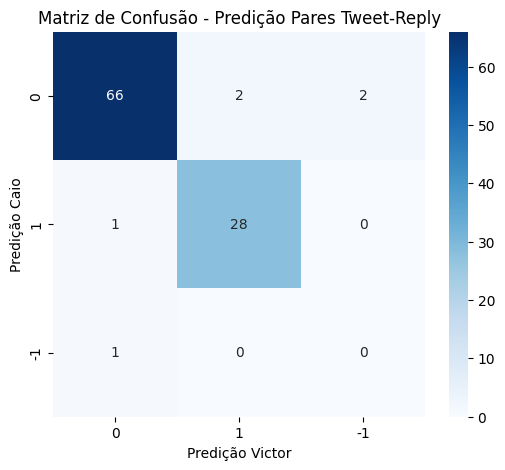

In [16]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Reply")
plt.show()

In [17]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Contei na abertura do 360: no último dia 22, o ministro Alexandre de Moraes deu 24 h para as redes sociais cumprirem a ordem judicial dada em MAIO. Ele tbm estabeleceu multa de R$ 20 mil por endereço que não fosse retirado do ar. #cnn360
Tweet 2:  Em contrapartida, a  dá espaço para o Roberto Jefferson continuar a atacar, caluniar e difamar seus desafetos de ocasião.  Diz muito sobre essa emissora.
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  O tiranete Alexandre de Moraes passou de todos os limites. Ele agora decide sozinho qual informação pode circular no país? Ele decide quem fala e quem cala a boca? Ou os democratas reagem agora a este ato de censura s/ precedentes ou não podem mais falar em liberdade de expressão
Tweet 2:  Democratas?? Isso existe do lado de lá??? #VozParaBernardoKuster
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Censura nunca mais.
Tweet 2:  Só vale para os amigo$. Ou não  ? #STFVergo

# **Pares Tweets-Quotes**

In [18]:
file_class_caio_quotes = "1go4VxUTBY7e7AGQdgdkEu6zq6BwP1k4g"
file_class_victor_quotes = "1rZl8lK5aXORRml5FV29YWbsf1mfz3FAX"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_quotes}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_quotes}"

gdown.download(url_1, "Contas_suspensas_quotes_caio.csv", quiet=False)
gdown.download(url_2, "Contas_suspensas_quotes_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1go4VxUTBY7e7AGQdgdkEu6zq6BwP1k4g
To: /content/Contas_suspensas_quotes_caio.csv
100%|██████████| 4.64M/4.64M [00:00<00:00, 95.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rZl8lK5aXORRml5FV29YWbsf1mfz3FAX
To: /content/Contas_suspensas_quotes_victor.csv
100%|██████████| 4.64M/4.64M [00:00<00:00, 24.5MB/s]


'Contas_suspensas_quotes_victor.csv'

In [19]:
df_caio_quotes = pd.read_csv ("Contas_suspensas_quotes_caio.csv")
df_victor_quotes = pd.read_csv ("Contas_suspensas_quotes_victor.csv")

In [20]:
df_caio_quotes = df_caio_quotes.iloc[:num_quotes_anotados,:]
df_victor_quotes = df_victor_quotes.iloc[:num_quotes_anotados,:]

In [21]:
confusion_quotes = np.zeros((3,3))


In [22]:
idx_diff_quotes = []

In [23]:
for i in range(df_caio_quotes.shape[0]):
  caio = int(df_caio_quotes.iloc[i]["Conflict"])
  victor = int(df_victor_quotes.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_quotes[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_quotes.append(i)


In [24]:
confusion_quotes

array([[88.,  1.,  2.],
       [ 0.,  9.,  0.],
       [ 0.,  0.,  0.]])

In [25]:
idx_diff_quotes

[28, 49, 87]

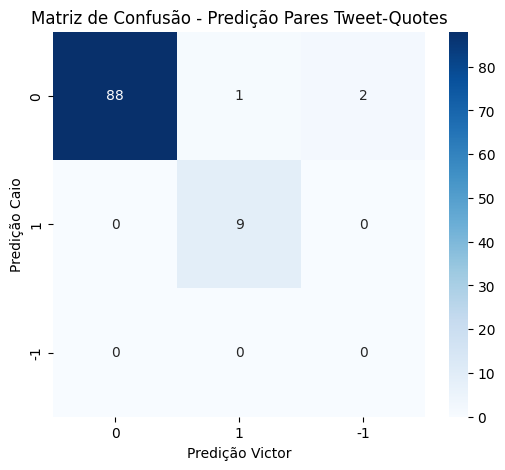

In [26]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_quotes, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Quotes")
plt.show()

In [27]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_quotes)):
  print("Tweet 1: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_1"])
  print("Tweet 2: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print()

Tweet 1:  Facebook e Twitter bloqueiam contas de investigados no inquérito das Fake News.  Contas bloqueadas: Allan dos Santos, Bernardo Kuster, Sara Geromini, Luciano Hang e Roberto Jefferson.
Tweet 2:  1. Esses caras são tão assumidamente petistas que têm PT até no nome do usuário!  2. Eu tô um gato nessa foto.
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  daora aplaudir grande dia remoção etc tuitando loucamente na mesma rede social que passou pano todos esses anos pra essa galera, com trocentas infrações de termos de uso e crimes potenciais, e de quebra ainda ajudar eles a bombarem nos tts retroalimentando a lógica sem parar
Tweet 2:  Não há o que comemorar
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Twitter suspende perfis pró-Bolsonaro por determinação de Alexandre de Moraes
Tweet 2:  Vc é uma vergonha uma desgraça pra nós brasileiros. #STFVergonhaNacional
Classificação Caio:  Não Conflito
Classificação Victor: 

# **Pares Tweets Originals**

In [28]:
file_class_caio_originals = "168Gv3z-KHSA6aza4TjQLVHNjx5syn371"
file_class_victor_originals = "1Kz5jQNJlYMI1DiIh0I-OLZQEYfESsLje"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_originals}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_originals}"

gdown.download(url_1, "Contas_suspensas_originals_caio.csv", quiet=False)
gdown.download(url_2, "Contas_suspensas_originals_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=168Gv3z-KHSA6aza4TjQLVHNjx5syn371
To: /content/Contas_suspensas_originals_caio.csv
100%|██████████| 2.94M/2.94M [00:00<00:00, 9.54MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Kz5jQNJlYMI1DiIh0I-OLZQEYfESsLje
To: /content/Contas_suspensas_originals_victor.csv
100%|██████████| 2.94M/2.94M [00:00<00:00, 27.6MB/s]


'Contas_suspensas_originals_victor.csv'

In [29]:
df_caio_originals = pd.read_csv ("Contas_suspensas_originals_caio.csv")
df_victor_originals = pd.read_csv ("Contas_suspensas_originals_victor.csv")

In [30]:
df_caio_originals = df_caio_originals.iloc[:num_originals_anotados,:]
df_victor_originals = df_victor_originals.iloc[:num_originals_anotados,:]

In [31]:
confusion_originals = np.zeros((3,3))


In [32]:
idx_diff_originals = []

In [33]:
for i in range(df_caio_originals.shape[0]):
  caio = int(df_caio_originals.iloc[i]["Conflict"])
  victor = int(df_victor_originals.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_originals[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_originals.append(i)

In [34]:
confusion_originals

array([[85.,  3.,  1.],
       [ 5.,  4.,  0.],
       [ 2.,  0.,  0.]])

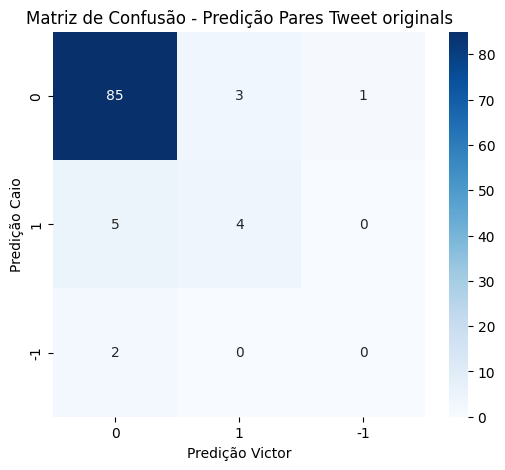

In [35]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_originals, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet originals")
plt.show()

In [36]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_originals)):
  print("Tweet 1: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_1"])
  print("Tweet 2: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_originals.loc[idx_diff_originals[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_originals.loc[idx_diff_originals[i], "Conflict"])])
  print()

Tweet 1:  Vejam agora no programa PINGO NOS IS o Roberto Jefferson aniquilando o STF
Tweet 2:  Mano, grande mídia é muito fraquinha, mesmo Os Pingos nos Ís  As vezes eu vejo só pra ter uma noção do tipo de informação que tá chegando no povo
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  qual a sua Opniao sobre a Censura  nas redes sociais ?, você sempre tão combativa e defensora dos direitos dos cidades a se manifestarem , não tenho visto sua Opniao a respeito ......
Tweet 2:  ROBERTO JEFFERSON DENUNCIA PERFIL FALSO EM SEU NOME E DEMONSTRA QUE STF USOU EXPEDIENTE INADEQUADO
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Censura não ajuda, não resolve problemas e não é positiva para a democracia do Brasil, nem para os brasileiros... isso precisa mudar PR  !  Após mandado de Moraes, Twitter derruba perfis de conservadores
Tweet 2:  Bom dia Rio Grande do AZUL !!! Um baita dia para todos aqui desta minha TIMEBLUE !!!
Classifi

In [37]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_replys = df_caio.drop('Conflict', axis = 1)
df_replys['Conflict_Caio'] = df_caio['Conflict']
df_replys['Conflict_Victor'] = df_victor['Conflict']

In [38]:
df_replys

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,Vocês também estão sentindo que o clima aqui n...,Comunista defendendo a censura. Nada de novo p...,1,1.0,1.0
1,O tiranete Alexandre de Moraes passou de todos...,Eu não consigo ler isso sem passar raiva desse...,1,0.0,0.0
2,O tiranete Alexandre de Moraes passou de todos...,"Isso é total ditadura!! Mas e o executivo , nã...",1,0.0,0.0
3,"Hoje, 24/07, Fakhoury e demais investigados pe...","... o PGR, Augusto Aras, já opinou pela conces...",1,0.0,0.0
4,É verdade que o Twitter derrubou várias contas...,"Dessa vez a culpa não foi do Twitter, e sim do...",1,0.0,0.0
...,...,...,...,...,...
95,"Por ordem de Alexandre de Moraes, Twitter canc...","Professor, para ver as contas que foram retida...",1,0.0,0.0
96,Vivemos em uma ditadura da toga #VozParaBernar...,Espalhar fakenews e discursos de ódio não tem ...,1,1.0,1.0
97,", não é Censura. Não é Crime de Opinião. Liber...",é censura sim... a lei já prevê os crimes cont...,1,1.0,1.0
98,Vivemos em uma ditadura da toga #VozParaBernar...,Bora levantar #VozParaBernardoKuster,1,0.0,0.0


In [39]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_quotes = df_caio_quotes.drop('Conflict',axis=1)
df_quotes['Conflict_Caio'] = df_caio_quotes['Conflict']
df_quotes['Conflict_Victor'] = df_victor_quotes['Conflict']

In [40]:
df_quotes

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,Corda pra se enforcar! #STFVergonhaNacional #...,...E a Democracia aos poucos vai se tornando r...,2,0.0,0.0
1,Mude a localização para acessar meus tweets: 1...,#VozParaBernardoKuster #STFVergonhaNacional M...,2,0.0,0.0
2,#URGENTE: Após pedido de Alexandre de Moraes (...,"Até quando iremos assistir inertes, atitudes a...",2,0.0,0.0
3,Já cancelou sua assinatura na grande mídia hoj...,"Daqui do EUA, eu sigo o Bernardo! #VozParaBern...",2,0.0,0.0
4,"Podem ter certeza, se fosse a conta do Nando M...",Mas não tenha NENHUMA DÚVIDA disso. Seria um g...,2,0.0,0.0
...,...,...,...,...,...
95,"Oi GALERA! Tô maus, mas já medicada. Não tenho...",STF vergonha. E tem Senador que Ameaça um Muni...,2,0.0,0.0
96,O primeiro país do mundo a usar tecnologia rob...,Ruanda que lindo isso,2,0.0,0.0
97,Mude a localização para acessar meus tweets: 1...,A internet é maravilhosa hahahaha censura não,2,0.0,0.0
98,A censura ao Bernardo Küster é abjeta e inacei...,Vamos à guerra! Por eles e por nós!!! #marchap...,2,0.0,0.0


In [41]:
#Organizando classificações de conflitos em originals de Caio e Victor em um unico DF
df_originals = df_caio_originals.drop('Conflict',axis=1)
df_originals['Conflict_Caio'] = df_caio_originals['Conflict']
df_originals['Conflict_Victor'] = df_victor_originals['Conflict']

In [42]:
df_originals

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,Guilherme Fiuza diz que Alexandre de Moraes nã...,Boletim das 17h01 do dia 24/07/2020 Situação ...,0,0.0,0.0
1,peço perdao pessoal nao e do meu feitio defend...,TWITTER DERRUBA CONTAS DOS DISSEMINADORES DE F...,0,0.0,0.0
2,Vejam agora no programa PINGO NOS IS o Roberto...,"Mano, grande mídia é muito fraquinha, mesmo Os...",0,0.0,1.0
3,Roberto Jefferson acaba de afirmar no Terça Li...,grande dia difícil,0,0.0,0.0
4,qual a sua Opniao sobre a Censura nas redes s...,ROBERTO JEFFERSON DENUNCIA PERFIL FALSO EM SEU...,0,0.0,-1.0
...,...,...,...,...,...
95,"""Deus quebre as mãos deles'' diz Roberto Jeffe...",Nossa mano são quase 8h e minha mãe já me mand...,0,0.0,0.0
96,"Hora Conservadora 25 - Fundeb, Censura, Poder ...",Afaste-se de quem comemora censura. E desmasca...,0,0.0,0.0
97,E teu pai que chamava de censura a suspensao d...,"É uma injustiça o , a e a não serem censurad...",0,1.0,1.0
98,caí no gemidão e acordei minha mae sem querer ...,CENSURA DO STF: Twitter cumpre decisão do mini...,0,0.0,0.0


In [43]:
#concatenando os datasets parciais:
df_contas_suspensas_classificado = pd.concat([df_originals, df_replys, df_quotes], ignore_index=True, axis = 0)
df_contas_suspensas_classificado

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,Guilherme Fiuza diz que Alexandre de Moraes nã...,Boletim das 17h01 do dia 24/07/2020 Situação ...,0,0.0,0.0
1,peço perdao pessoal nao e do meu feitio defend...,TWITTER DERRUBA CONTAS DOS DISSEMINADORES DE F...,0,0.0,0.0
2,Vejam agora no programa PINGO NOS IS o Roberto...,"Mano, grande mídia é muito fraquinha, mesmo Os...",0,0.0,1.0
3,Roberto Jefferson acaba de afirmar no Terça Li...,grande dia difícil,0,0.0,0.0
4,qual a sua Opniao sobre a Censura nas redes s...,ROBERTO JEFFERSON DENUNCIA PERFIL FALSO EM SEU...,0,0.0,-1.0
...,...,...,...,...,...
295,"Oi GALERA! Tô maus, mas já medicada. Não tenho...",STF vergonha. E tem Senador que Ameaça um Muni...,2,0.0,0.0
296,O primeiro país do mundo a usar tecnologia rob...,Ruanda que lindo isso,2,0.0,0.0
297,Mude a localização para acessar meus tweets: 1...,A internet é maravilhosa hahahaha censura não,2,0.0,0.0
298,A censura ao Bernardo Küster é abjeta e inacei...,Vamos à guerra! Por eles e por nós!!! #marchap...,2,0.0,0.0


In [44]:
df_contas_suspensas_classificado.to_csv("contas_suspensas_classificado.csv", index=False, encoding="utf-8")
files.download("contas_suspensas_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [45]:
div_reply = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_reply['Conflict'] = np.nan
div_quotes = df_caio_quotes.iloc[idx_diff_quotes].drop('Conflict', axis=1)
div_quotes['Conflict'] = np.nan
div_originals = df_caio_originals.iloc[idx_diff_originals].drop('Conflict', axis=1)
div_originals['Conflict'] = np.nan

In [46]:
div_reply.shape

(6, 4)

In [47]:
div_quotes.shape

(3, 4)

In [48]:
div_originals.shape

(11, 4)

In [49]:
div_contas_suspensas = pd.concat([div_originals, div_reply, div_quotes], ignore_index=True, axis = 0)

In [50]:
div_contas_suspensas.shape

(20, 4)

In [51]:
div_contas_suspensas.to_csv("divergencias_contas_suspensas.csv", index=False, encoding="utf-8")
files.download("divergencias_contas_suspensas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**

In [52]:
conv_reply = df_caio.drop(index=idx_diff, errors='ignore')
conv_quotes = df_caio_quotes.drop(index=idx_diff_quotes, errors='ignore')
conv_originals = df_caio_originals.drop(index=idx_diff_originals, errors='ignore')

In [53]:
conv_reply.shape

(94, 4)

In [54]:
conv_contas_suspensas = pd.concat([conv_originals, conv_reply, conv_quotes], ignore_index=True, axis = 0)

In [55]:
conv_contas_suspensas

,tweet_1,tweet_2,Class,Conflict
0,Guilherme Fiuza diz que Alexandre de Moraes nã...,Boletim das 17h01 do dia 24/07/2020 Situação ...,0,0.0
1,peço perdao pessoal nao e do meu feitio defend...,TWITTER DERRUBA CONTAS DOS DISSEMINADORES DE F...,0,0.0
2,Roberto Jefferson acaba de afirmar no Terça Li...,grande dia difícil,0,0.0
3,#STFVergonhaNacional bando de lixo,Essa música vem acalhar nesse momento de censu...,0,0.0
4,"Quem comemora a censura hoje, chora amanhã por...","""No último ano e meio, a militância bolsonaris...",0,1.0
...,...,...,...,...
275,"Oi GALERA! Tô maus, mas já medicada. Não tenho...",STF vergonha. E tem Senador que Ameaça um Muni...,2,0.0
276,O primeiro país do mundo a usar tecnologia rob...,Ruanda que lindo isso,2,0.0
277,Mude a localização para acessar meus tweets: 1...,A internet é maravilhosa hahahaha censura não,2,0.0
278,A censura ao Bernardo Küster é abjeta e inacei...,Vamos à guerra! Por eles e por nós!!! #marchap...,2,0.0


In [56]:
conv_contas_suspensas.to_csv("convergencias_contas_suspensas.csv", index=False, encoding="utf-8")
files.download("convergencias_contas_suspensas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>